#  Marketing Campaign Analysis  
## Course-End Project 2  – Data Analytics with Python  
# Name- Pragya Raghuwanshi

###  Objective  
To analyze marketing campaign data and derive insights about customer behavior and campaign effectiveness.

###  Description  
This project focuses on data cleaning, feature engineering, exploratory data analysis (EDA), hypothesis testing, and visualization to understand factors influencing customer acquisition.

# 🔹 Step 1: Data Import  

In this step, we import required libraries and load the dataset. We also check the structure of the data including data types and missing values.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset
data = pd.read_csv("marketing_data.csv")

# Preview data
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [2]:
# Check structure and missing values
data.info()
data.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   2240 non-null   int64
 1   Year_Birth           2240 non-null   int64
 2   Education            2240 non-null   str  
 3   Marital_Status       2240 non-null   str  
 4    Income              2216 non-null   str  
 5   Kidhome              2240 non-null   int64
 6   Teenhome             2240 non-null   int64
 7   Dt_Customer          2240 non-null   str  
 8   Recency              2240 non-null   int64
 9   MntWines             2240 non-null   int64
 10  MntFruits            2240 non-null   int64
 11  MntMeatProducts      2240 non-null   int64
 12  MntFishProducts      2240 non-null   int64
 13  MntSweetProducts     2240 non-null   int64
 14  MntGoldProds         2240 non-null   int64
 15  NumDealsPurchases    2240 non-null   int64
 16  NumWebPurchases      2240 non-null 

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

# 🔹 Step 2: Investigate Variables  

We clean important variables like Income and convert date columns into proper format.


In [3]:
# Step 1: Clean column names 
data.columns = data.columns.str.strip()

# Step 2: Check columns 
print(data.columns)

# Step 3: Clean Income column
data['Income'] = data['Income'].replace({r'\$':'', ',':''}, regex=True).astype(float)

# Step 4: Convert date column
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'])

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='str')


C:\Users\Pragya Raghuwanshi\AppData\Local\Temp\ipykernel_3140\2510879015.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'])


# 🔹 Step 3: Missing Value Imputation  

We handle missing values and clean categorical variables.

In [4]:
# Check missing values
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [5]:
# Clean categorical columns
data['Education'] = data['Education'].replace({
    '2n Cycle':'Master',
    'Graduation':'Graduate'
})

data['Marital_Status'] = data['Marital_Status'].replace({
    'Together':'Married',
    'Alone':'Single'
})

In [6]:
# Fill missing Income
data['Income'] = data.groupby(['Education','Marital_Status'])['Income']\
                     .transform(lambda x: x.fillna(x.mean()))

# 🔹 Step 4: Feature Engineering  

We create new useful variables such as Age, Spending, Children Count, etc.

In [7]:
# Age
data['Age'] = 2024 - data['Year_Birth']

# Total Spending
data['Spending'] = data[['MntWines','MntFruits','MntMeatProducts',
                        'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

# Children Count
data['Children_Count'] = data['Kidhome'] + data['Teenhome']

# Has Children
data['Has_Children'] = data['Children_Count'].apply(lambda x: 1 if x > 0 else 0)

# Total Purchases
data['Total_Purchases'] = data[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(axis=1)

# 🔹 Step 5: Boxplots & Histograms  

We visualize distributions and detect outliers.

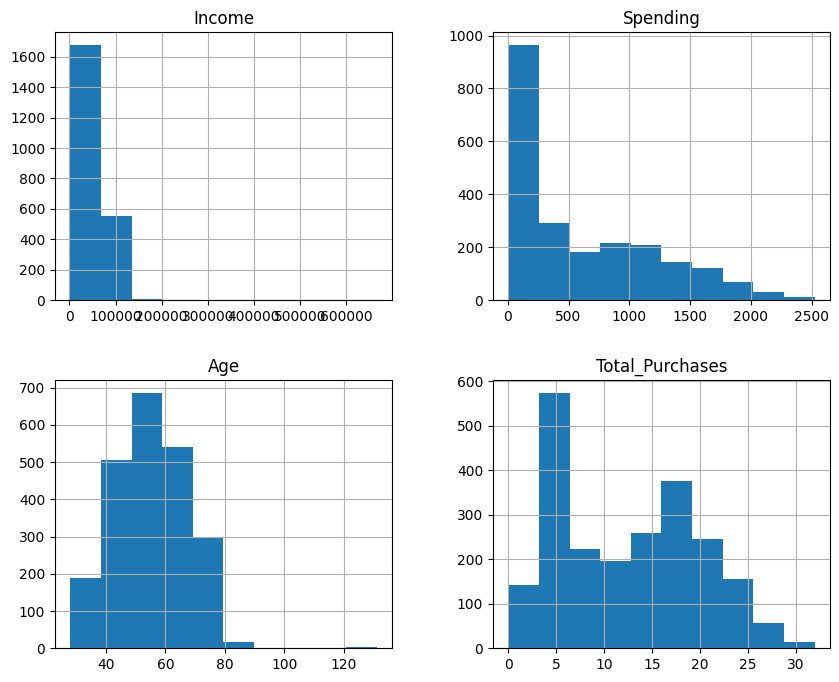

In [8]:
# Histograms
data[['Income','Spending','Age','Total_Purchases']].hist(figsize=(10,8))
plt.show()

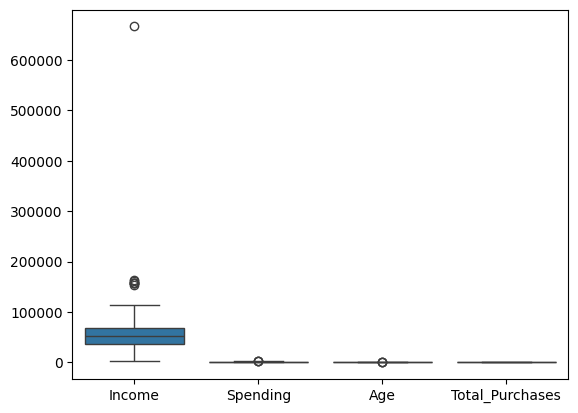

In [9]:
# Boxplots
sns.boxplot(data=data[['Income','Spending','Age','Total_Purchases']])
plt.show()

In [10]:
# Outlier treatment (capping)
for col in ['Income','Spending']:
    upper = data[col].quantile(0.95)
    lower = data[col].quantile(0.05)
    data[col] = np.clip(data[col], lower, upper)

# 🔹 Step 6: Encoding  

We convert categorical variables into numerical format.

In [11]:
# Ordinal Encoding
education_order = {'Basic':1, 'Graduate':2, 'Master':3, 'PhD':4}
data['Education'] = data['Education'].map(education_order)

# One-hot encoding
data = pd.get_dummies(data, columns=['Country','Marital_Status'], drop_first=True)

# 🔹 Step 7: Correlation Analysis  

We analyze relationships between variables using a heatmap.

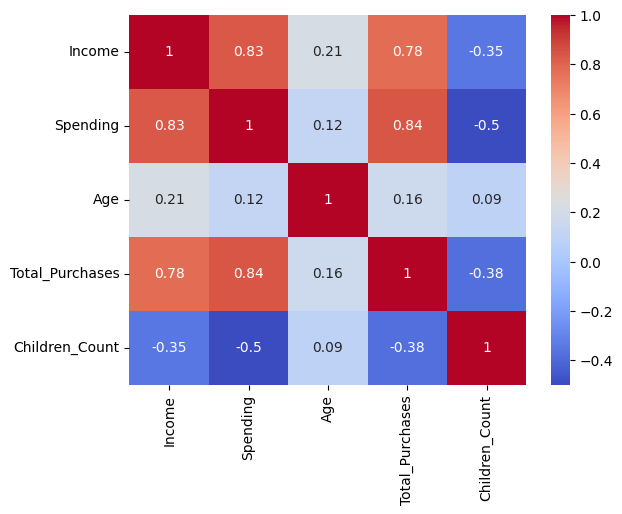

In [12]:
var_cor = ['Income','Spending','Age','Total_Purchases','Children_Count']
corr = data[var_cor].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# 🔹 Step 8: Hypothesis Testing  

We perform statistical testing to check if income affects campaign response.

In [13]:
accepted = data[data['Response']==1]['Income']
not_accepted = data[data['Response']==0]['Income']

stats.ttest_ind(accepted, not_accepted)

TtestResult(statistic=np.float64(7.7498410390797074), pvalue=np.float64(1.3850374879354997e-14), df=np.float64(2238.0))

# 🔹 Step 9: Visualization  

We analyze patterns using different plots.

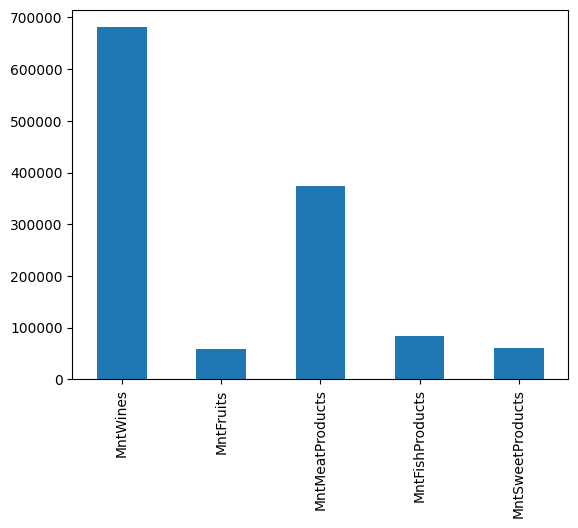

In [14]:
# Product performance
prod_data = data[['MntWines','MntFruits','MntMeatProducts',
                  'MntFishProducts','MntSweetProducts']].sum()

prod_data.plot(kind='bar')
plt.show()

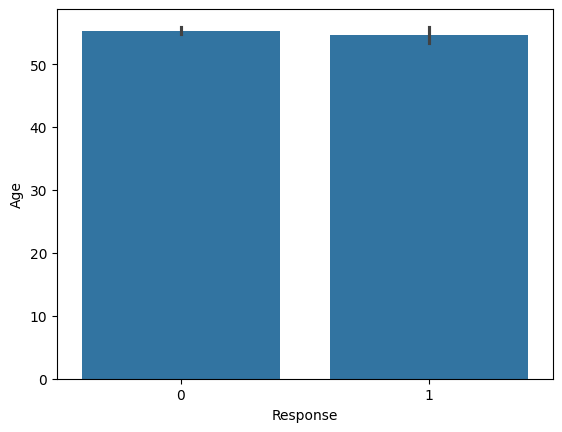

In [15]:
# Age vs Campaign
sns.barplot(x='Response', y='Age', data=data)
plt.show()

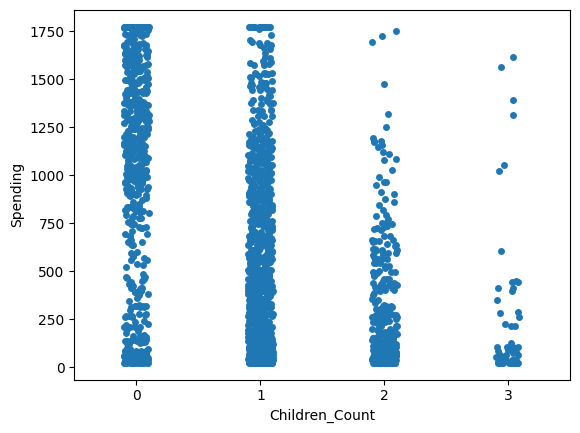

In [16]:
# Children vs Spending
sns.stripplot(x='Children_Count', y='Spending', data=data)
plt.show()

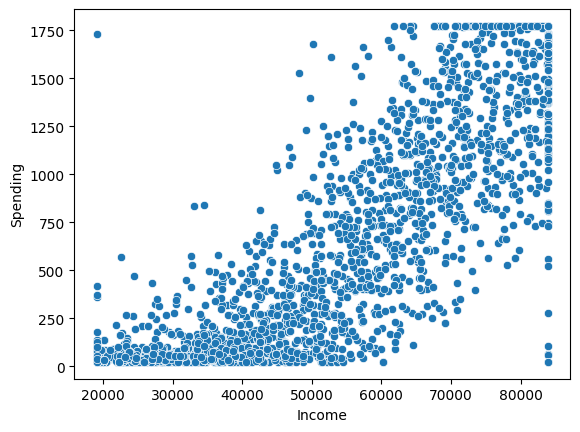

In [17]:
# Income vs Spending
sns.scatterplot(x='Income', y='Spending', data=data)
plt.show()

#  Conclusion  

- Higher income customers tend to spend more  
- Campaign acceptance is influenced by income  
- Customers with fewer children spend more  
- Certain products generate higher revenue  
- Targeted marketing strategies can improve performance  

 This project demonstrates how data analysis helps in better decision-making.